In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("./src/kashti.csv")
df

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
# retain only age fare survived columns
df = df[['age', 'fare', 'survived','sibsp']]
df.head()

,age,fare,survived,sibsp
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


## Mean/Median Imputation

In [5]:
df.isnull().mean()

age         0.198653
fare        0.000000
survived    0.000000
sibsp       0.000000
dtype: float64

In [6]:
x = df.drop('survived', axis=1)
y = df['survived']

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
x_train.shape

(712, 3)

In [11]:
x_train.isnull().mean()

age      0.196629
fare     0.000000
sibsp    0.000000
dtype: float64

In [12]:
x_test.isnull().mean()

age      0.206704
fare     0.000000
sibsp    0.000000
dtype: float64

### Imputation By Pandas

In [13]:
mean_age = x_train['age'].mean()
median_age = x_train['age'].median()


In [14]:
x_train['age mean'] = x_train['age'].fillna(mean_age)
x_train['age median'] = x_train['age'].fillna(median_age)

In [17]:
x_train.sample(5)

,age,fare,sibsp,age mean,age median
887,19.0,30.00,0,19.000000,19.0
403,28.0,15.85,1,28.000000,28.0
53,29.0,26.00,1,29.000000,29.0
841,16.0,10.50,0,16.000000,16.0
740,NaN,30.00,0,29.498846,28.0


In [18]:
print("Original Age Variance:", x_train['age'].var())
print("Mean Imputed Age Variance:", x_train['age mean'].var())
print("Median Imputed Age Variance:", x_train['age median'].var())

Original Age Variance: 210.2517072477435
Mean Imputed Age Variance: 168.85193366872227
Median Imputed Age Variance: 169.20731007048155


<Axes: ylabel='Density'>

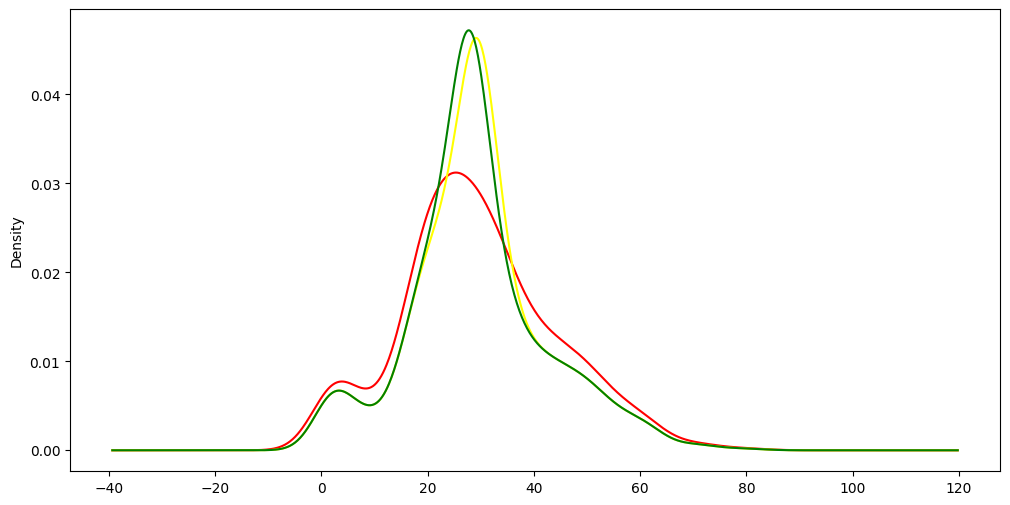

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.subplot(111)
x_train['age'].plot(kind='kde', label='Original Age', color='red')
x_train['age mean'].plot(kind='kde', label='Mean Imputed Age', color='yellow')
x_train['age median'].plot(kind='kde', label='Median Imputed Age', color='green')

In [20]:
x_train.cov()

,age,fare,sibsp,age mean,age median
age,210.251707,71.580633,-4.501273,210.251707,210.251707
fare,71.580633,2700.831981,9.354652,57.485994,61.261919
sibsp,-4.501273,9.354652,1.383927,-3.614946,-3.637141
age mean,210.251707,57.485994,-3.614946,168.851934,168.851934
age median,210.251707,61.261919,-3.637141,168.851934,169.207310


In [21]:
x_train.corr()

,age,fare,sibsp,age mean,age median
age,1.000000,0.088103,-0.320916,1.000000,1.000000
fare,0.088103,1.000000,0.153011,0.085126,0.090622
sibsp,-0.320916,0.153011,1.000000,-0.236479,-0.237681
age mean,1.000000,0.085126,-0.236479,1.000000,0.998949
age median,1.000000,0.090622,-0.237681,0.998949,1.000000


<Axes: >

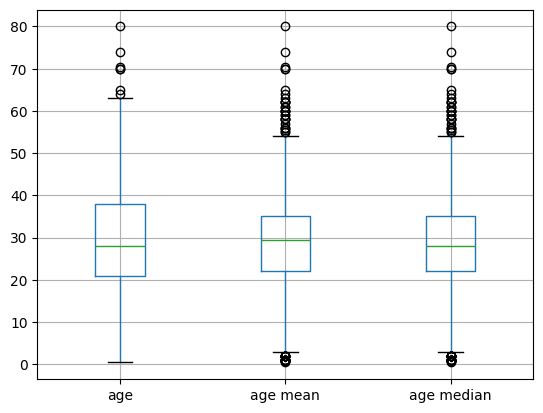

In [22]:
x_train[['age', 'age mean', 'age median']].boxplot()

for age mean/median imputation is not good as the missing values are around 20% and it is causing the changes in the distribution, new outliers are coming in and covariance/correlation also got changes with other variables

### Imputation By SkLearn

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [30]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['age']),
    ('imputer2', imputer2, ['age'])
], remainder='passthrough')

In [31]:
trf.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [32]:
trf.named_transformers_['imputer1'].statistics_

array([29.49884615])

In [33]:
trf.named_transformers_['imputer2'].statistics_

array([28.])

In [34]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)
x_train

array([[ 45.5   ,  45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  23.    ,  13.    ,   0.    ],
       [ 32.    ,  32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  41.    ,  14.1083,   2.    ],
       [ 14.    ,  14.    , 120.    ,   1.    ],
       [ 21.    ,  21.    ,  77.2875,   0.    ]], shape=(712, 4))

## Arbitrary Value Imputation
- use any number that is not in the data so that model can identify where data does not exist

In [45]:
df1 = pd.read_csv("./src/kashti.csv")
df1

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [46]:
df2 = df1[['age', 'fare', 'survived','sibsp']]
df2.head()

,age,fare,survived,sibsp
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [53]:
x1 = df2.drop('survived', axis=1)
y1 = df2['survived']

In [54]:
x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2, random_state=42)

In [55]:
x_train['age_99'] = x_train['age'].fillna("99")
x_train['age_-1'] = x_train['age'].fillna("-1")

In [61]:
x_train.tail()

,age,fare,sibsp,age_99,age_-1
106,21.0,7.6500,0,21.0,21.0
270,NaN,31.0000,0,99,-1
860,41.0,14.1083,2,41.0,41.0
435,14.0,120.0000,1,14.0,14.0
102,21.0,77.2875,0,21.0,21.0


In [64]:
x_train['age'] = pd.to_numeric(x_train['age'], errors='coerce')
x_train['age_99'] = pd.to_numeric(x_train['age_99'], errors='coerce')
x_train['age_-1'] = pd.to_numeric(x_train['age_-1'], errors='coerce')

In [66]:
print("Original Age Variance:", x_train['age'].var())
print("99 Imputed Age Variance:", x_train['age_99'].var())
print("-1 Imputed Age Variance:", x_train['age_-1'].var())

Original Age Variance: 210.2517072477435
99 Imputed Age Variance: 932.9665366701432
-1 Imputed Age Variance: 315.9955036260055


<Axes: ylabel='Density'>

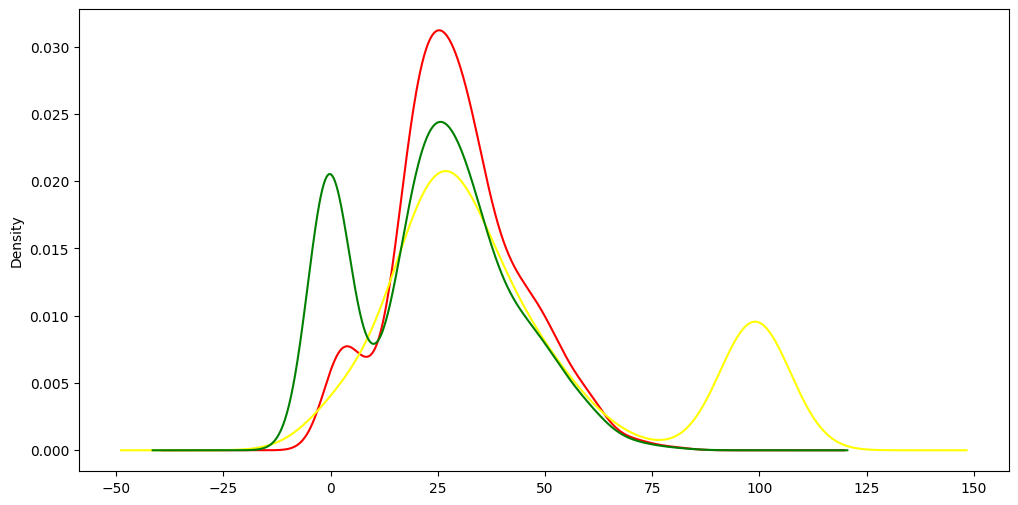

In [67]:
fig = plt.figure(figsize=(12, 6))
plt.subplot(111)
x_train['age'].plot(kind='kde', label='Original Age', color='red')
x_train['age_99'].plot(kind='kde', label='99 Imputed Age', color='yellow')
x_train['age_-1'].plot(kind='kde', label='-1 Imputed Age', color='green')

<Axes: >

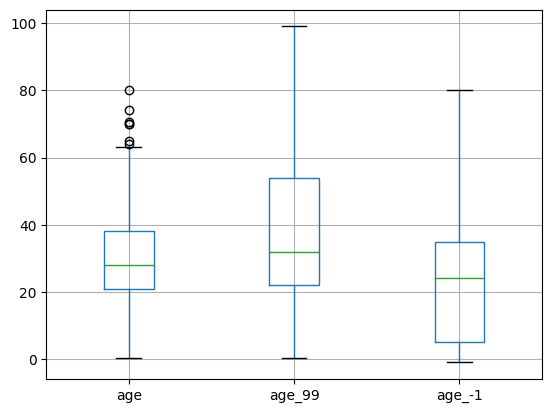

In [68]:
x_train[['age', 'age_99', 'age_-1']].boxplot()